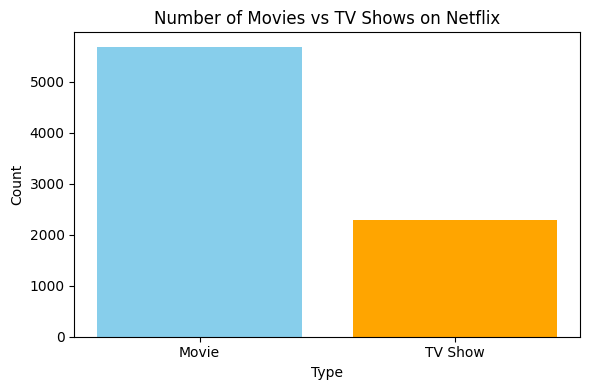

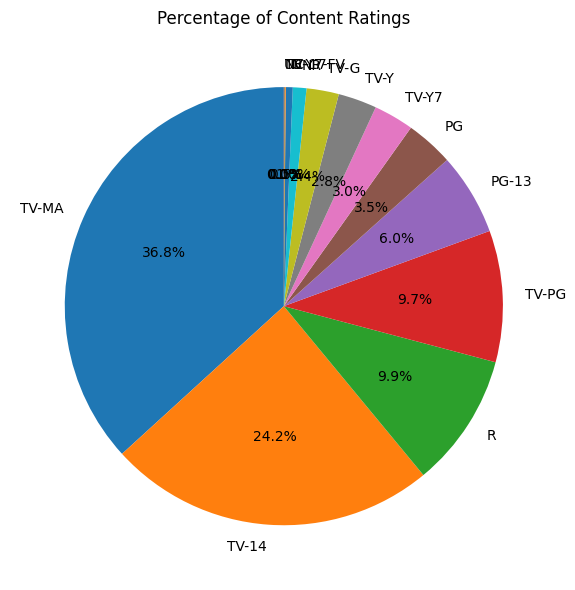

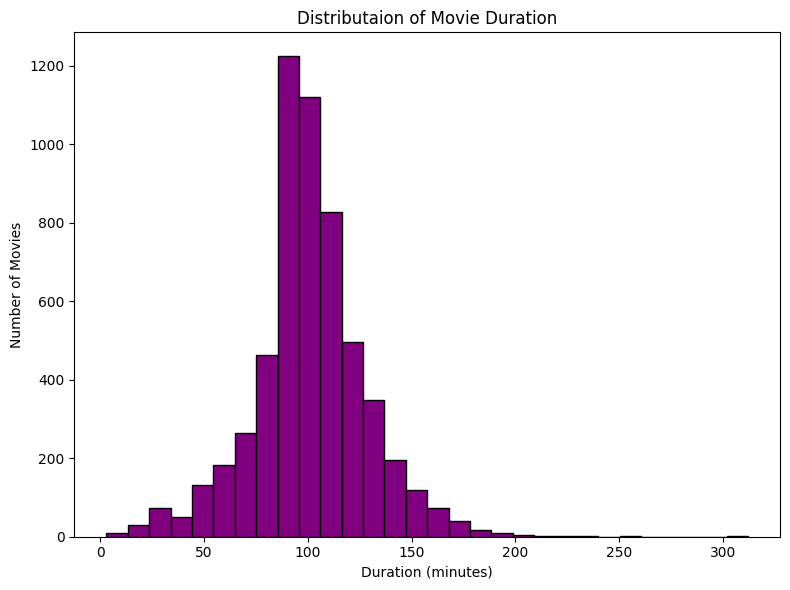

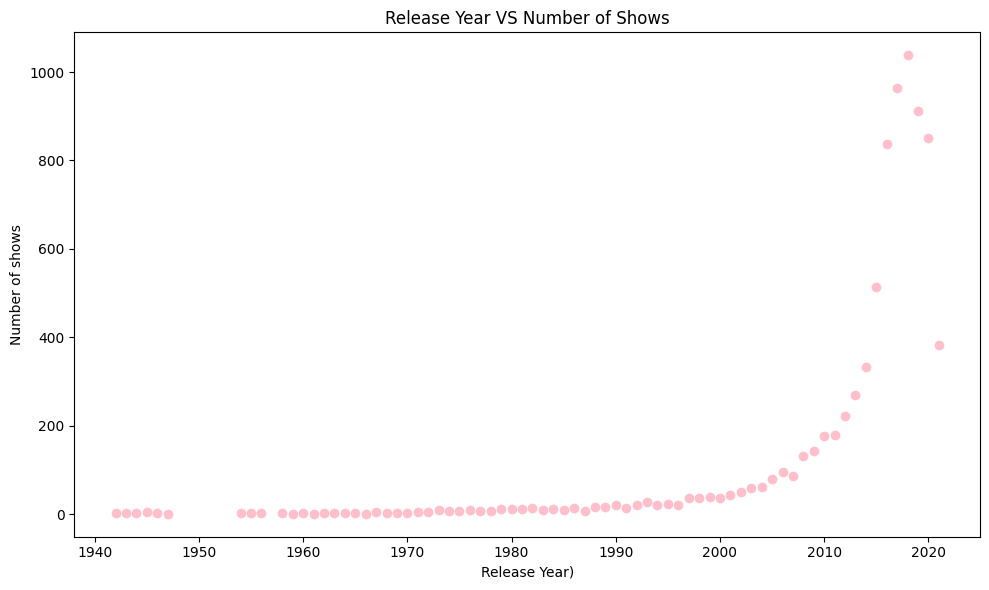

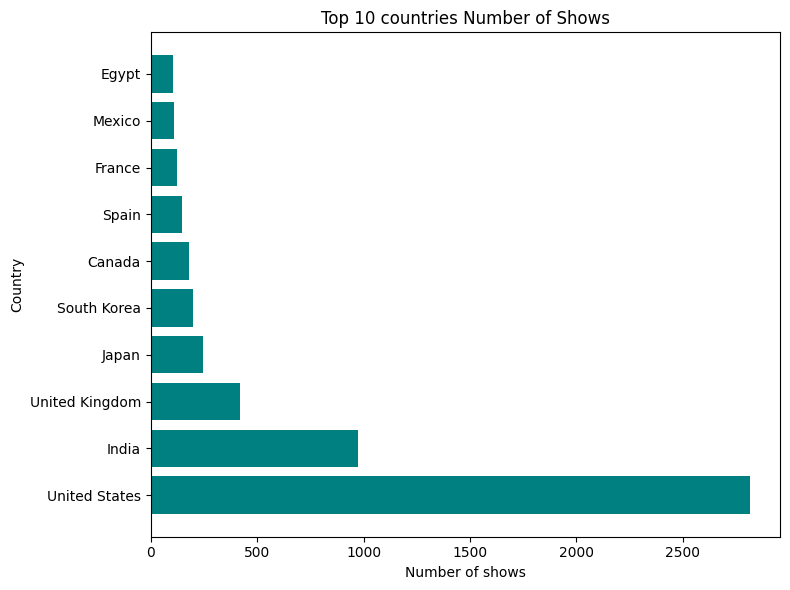

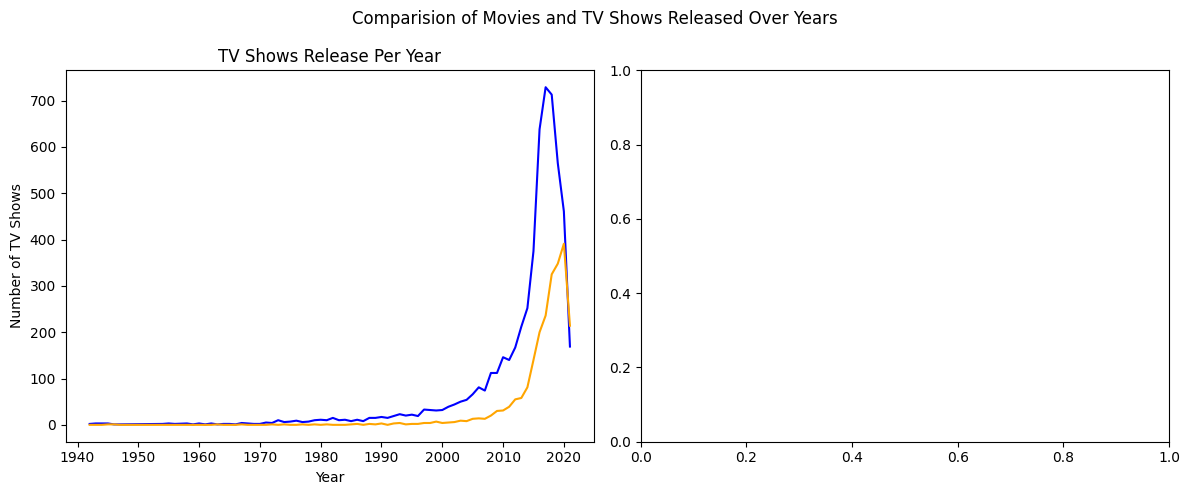

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('Netflix.csv')
df = df.dropna(subset=['type' , 'release_year' , 'country' ,'duration'])

type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color=['skyblue', 'orange'])
plt.title('Number of Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()

rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Content Ratings')
plt.tight_layout()
plt.savefig('Content_Ratings_pie.png')
plt.show()

movie_df =df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace('min', '').astype(int)
plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'], bins=30, color='purple', edgecolor='black')
plt.title('Distributaion of Movie Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('movie_duration_histogram.png')
plt.show()

release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index, release_counts.values, color='pink')
plt.title('Release Year VS Number of Shows')
plt.xlabel('Release Year)')
plt.ylabel('Number of shows')
plt.tight_layout()
plt.savefig('release_year_scatter.png')
plt.show()


country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values, color='teal')
plt.title('Top 10 countries Number of Shows')
plt.xlabel('Number of shows')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top10_countries.png')
plt.show()

content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)
fig, ax = plt.subplots(1,2, figsize=(12,5))
#first subolot:movies
ax[0].plot(content_by_year.index,content_by_year['Movie'], color='blue')
ax[0].set_title('Movies Release Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')

#second subolot:TV Shows
ax[0].plot(content_by_year.index,content_by_year['TV Show'], color='orange')
ax[0].set_title('TV Shows Release Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of TV Shows')

fig.suptitle('Comparision of Movies and TV Shows Released Over Years')
plt.tight_layout()
plt.savefig('movies_tv_shows_comparision.png')
plt.show()